<a href="https://colab.research.google.com/github/data602sps/assignments/blob/master/05_assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Assignment 8**

# **Weeks 10 & 11- matplotlib & seaborn**
* In this homework assignment, you will explore and analyze a public dataset of your choosing. Since this assignment is “open-ended” in nature, you are free to expand upon the requirements below. However, you must meet the minimum requirments as indicated in each section.


* The preferred method for this analysis is in a .ipynb file. Feel free to use whichever platform of your choosing.  


### **Some data examples:**
•	https://www.data.gov/

•	https://opendata.cityofnewyork.us/

•	https://datasetsearch.research.google.com/

•	https://archive.ics.uci.edu/ml/index.php

### **Resources:**

•	https://pandas.pydata.org/pandas-docs/stable/getting_started/10min.html

•	https://www.oreilly.com/library/view/python-data-science/9781491912126/ch04.html

•	https://www.data-to-viz.com/



### **Headings or comments**
**You are required to make use of comments, or headings for each section.  You must explain what your code is doing, and the results of running your code.**  Act as if you were giving this assignment to your manager - you must include clear and descriptive information for each section.

### **You may work as a group or indivdually on this assignment.**


# Introduction

In this section, please describe the dataset you are using.  Include a link to the source of this data.  You should also provide some explanation on why you choose this dataset.

For this assignment, I used the Palmer Penguins dataset. This dataset contains measurements for penguins from three species: Adelie, Chinstrap, and Gentoo. The variables include bill length, bill depth, flipper length, body mass, sex, island, and year.

Source: https://github.com/allisonhorst/palmerpenguins

I chose this dataset because it is clean, easy to understand, and has both numerical and categorical variables. That makes it a good choice for practicing data exploration, data wrangling, and visualizations with both matplotlib and seaborn.

______________
# Data Exploration
Import your dataset into your .ipynb, create dataframes, and explore your data.  

Include:

* Summary statistics means, medians, quartiles,
* Missing value information
* Any other relevant information about the dataset.  



In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset from seaborn
df = sns.load_dataset("penguins")

# Display the first 5 rows
print("First 5 rows of the dataset:")
display(df.head())

# General information
print("Dataset shape:", df.shape)
print("\nColumn names:")
print(df.columns)

print("\nData types:")
print(df.dtypes)

# Summary statistics for numerical columns
print("\nSummary statistics:")
display(df.describe())

# Median values
print("\nMedian values:")
display(df.median(numeric_only=True))

# Quartiles
print("\nQuartiles:")
display(df.quantile([0.25, 0.50, 0.75], numeric_only=True))

# Missing values
print("\nMissing values in each column:")
display(df.isnull().sum())

# Value counts for species
print("\nNumber of penguins by species:")
display(df["species"].value_counts())

# Value counts for island
print("\nNumber of penguins by island:")
display(df["island"].value_counts())

First 5 rows of the dataset:


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female


Dataset shape: (344, 7)

Column names:
Index(['species', 'island', 'bill_length_mm', 'bill_depth_mm',
       'flipper_length_mm', 'body_mass_g', 'sex'],
      dtype='object')

Data types:
species               object
island                object
bill_length_mm       float64
bill_depth_mm        float64
flipper_length_mm    float64
body_mass_g          float64
sex                   object
dtype: object

Summary statistics:


,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
count,342.000000,342.000000,342.000000,342.000000
mean,43.921930,17.151170,200.915205,4201.754386
std,5.459584,1.974793,14.061714,801.954536
min,32.100000,13.100000,172.000000,2700.000000
25%,39.225000,15.600000,190.000000,3550.000000
50%,44.450000,17.300000,197.000000,4050.000000
75%,48.500000,18.700000,213.000000,4750.000000
max,59.600000,21.500000,231.000000,6300.000000



Median values:


...

,0
species,0
island,0
bill_length_mm,2
bill_depth_mm,2
flipper_length_mm,2
body_mass_g,2
sex,11



Number of penguins by species:


,count
species,
Adelie,152
Gentoo,124
Chinstrap,68



Number of penguins by island:


,count
island,
Biscoe,168
Dream,124
Torgersen,52


### Data Exploration Summary

The dataset contains both numerical and categorical variables. The summary statistics show that body mass and flipper length vary significantly across penguins. There are some missing values, particularly in the sex column, which were handled in the data wrangling step.

# Data Wrangling

Perform data wrangling.  You are free to use your best judgment here.  If you are stuck, look at previous assignment.

In [2]:
# Create a copy for wrangling
penguins_clean = df.copy()

# Remove rows with missing values in key columns used for analysis
penguins_clean = penguins_clean.dropna(subset=[
    "species", "bill_length_mm", "bill_depth_mm",
    "flipper_length_mm", "body_mass_g", "sex"
])

# Standardize text columns
penguins_clean["sex"] = penguins_clean["sex"].str.capitalize()
penguins_clean["species"] = penguins_clean["species"].str.strip()

# Create a body mass column in kilograms
penguins_clean["body_mass_kg"] = penguins_clean["body_mass_g"] / 1000

# Check cleaned data
print("Cleaned dataset shape:", penguins_clean.shape)
print("\nMissing values after cleaning:")
display(penguins_clean.isnull().sum())

print("\nFirst 5 rows of cleaned dataset:")
display(penguins_clean.head())

Cleaned dataset shape: (333, 8)

Missing values after cleaning:


,0
species,0
island,0
bill_length_mm,0
bill_depth_mm,0
flipper_length_mm,0
body_mass_g,0
sex,0
body_mass_kg,0



First 5 rows of cleaned dataset:


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,body_mass_kg
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male,3.75
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female,3.80
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female,3.25
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female,3.45
5,Adelie,Torgersen,39.3,20.6,190.0,3650.0,Male,3.65


### Data Wrangling Summary

Rows with missing values were removed to ensure accurate analysis. Text fields were cleaned for consistency, and a new variable (body_mass_kg) was created for easier interpretation. The cleaned dataset is now ready for visualization.

# Visualizations

The main purpose of this assignment is to practice creating various visualizations using the matplotlib and seaborn library.

### **Part 1:**
Using matplotlib, create ***two or more plots*** that incorporate at least **5** of the following properties:

Note: these properties vary based on your data.  The goal is to practice creating visualizations and modifying its properties.

*   Use and change a legend position
*   Change a legend font size
*   Place a legend outside of the plot
*   Create a single legend for all subplots
*   Change the title and x/y labels
*   Change the marker, line colors, and line width
*   Add annotations
*   Modify Axis Text Ticks/Labels
*   Change size of axis Labels
*   Your own choice not included above


Plots that you can create **include**:

*   Scatter Plot
*   Bar plot
*   Line Chart
*   Multi Plots (e.g. using .subplot()
*   Histogram

You can add another plot not listed here if it works better for your data.  This is not a complete list of plots to create.

### **Part 2:**

Recreate the visualizations above using the Seaborn library as best as possible.  


**You are required to explain what each of your plots is representing. Plots without comments will not be accepted.**  In addition, please explain the properties you are showcasing.


### **Part 3:**
In a comment or text box, explain the differences between creating a plot in matplotlib and seaborn, based on your above plots.



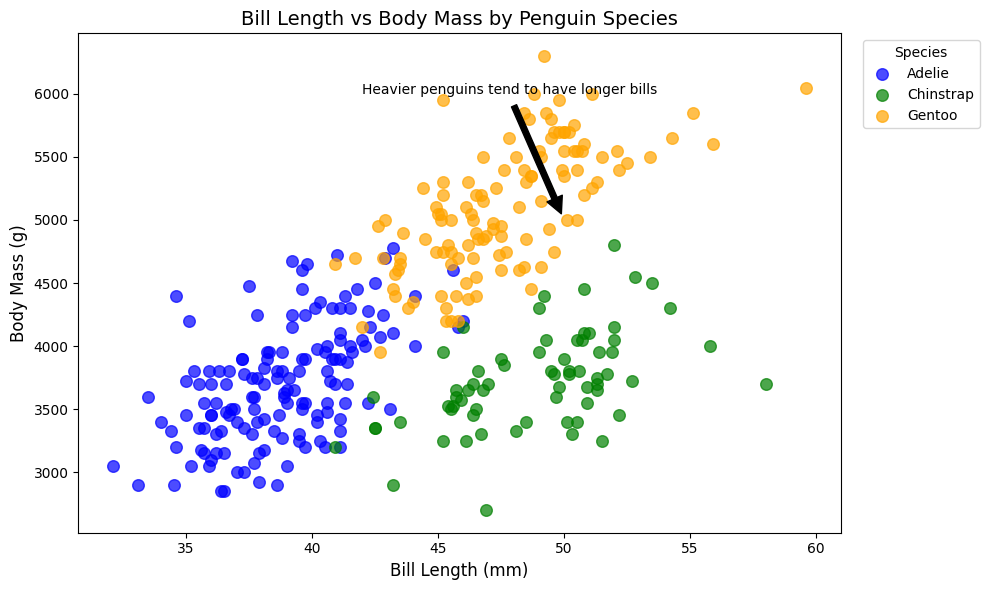

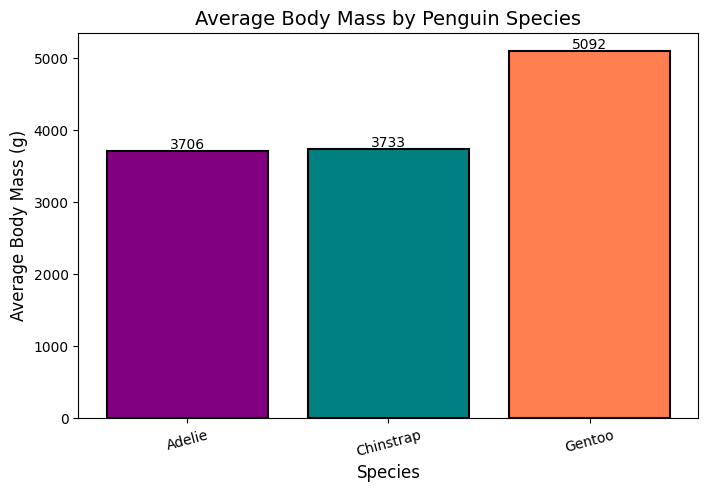

In [5]:
# Part 1
# Matplotlib scatter plot
fig, ax = plt.subplots(figsize=(10, 6))

species_list = penguins_clean["species"].unique()
colors = ["blue", "green", "orange"]

for species, color in zip(species_list, colors):
    subset = penguins_clean[penguins_clean["species"] == species]
    ax.scatter(
        subset["bill_length_mm"],
        subset["body_mass_g"],
        label=species,
        color=color,
        s=70,
        alpha=0.7
    )

ax.set_title("Bill Length vs Body Mass by Penguin Species", fontsize=14)
ax.set_xlabel("Bill Length (mm)", fontsize=12)
ax.set_ylabel("Body Mass (g)", fontsize=12)

# Move legend outside
ax.legend(title="Species", loc="upper left", bbox_to_anchor=(1.02, 1), fontsize=10)

# Modify tick labels
ax.tick_params(axis='both', labelsize=10)

# Add annotation
ax.annotate(
    "Heavier penguins tend to have longer bills",
    xy=(50, 5000),
    xytext=(42, 6000),
    arrowprops=dict(facecolor="black", shrink=0.05),
    fontsize=10
)

plt.tight_layout()
plt.show()

# Matpolib bar plot
# Average body mass by species
avg_mass = penguins_clean.groupby("species")["body_mass_g"].mean().sort_values()

fig, ax = plt.subplots(figsize=(8, 5))

bars = ax.bar(
    avg_mass.index,
    avg_mass.values,
    color=["purple", "teal", "coral"],
    edgecolor="black",
    linewidth=1.5
)

ax.set_title("Average Body Mass by Penguin Species", fontsize=14)
ax.set_xlabel("Species", fontsize=12)
ax.set_ylabel("Average Body Mass (g)", fontsize=12)

# Rotate x labels
plt.xticks(rotation=15, fontsize=10)

# Add value annotations
for bar in bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width()/2,
        height + 40,
        f"{height:.0f}",
        ha="center",
        fontsize=10
    )

plt.show()




## Part 1
### Matplotlib Scatter Plot

This plot shows the relationship between bill length and body mass across penguin species. There is a visible positive relationship, meaning penguins with longer bills tend to have higher body mass. Different colors represent different species, making it easy to compare groups.

### Matplotlib Bar Plot

This plot compares the average body mass across penguin species. Gentoo penguins have the highest average body mass, while Adelie and Chinstrap are lower. The annotations help clearly show the exact values.

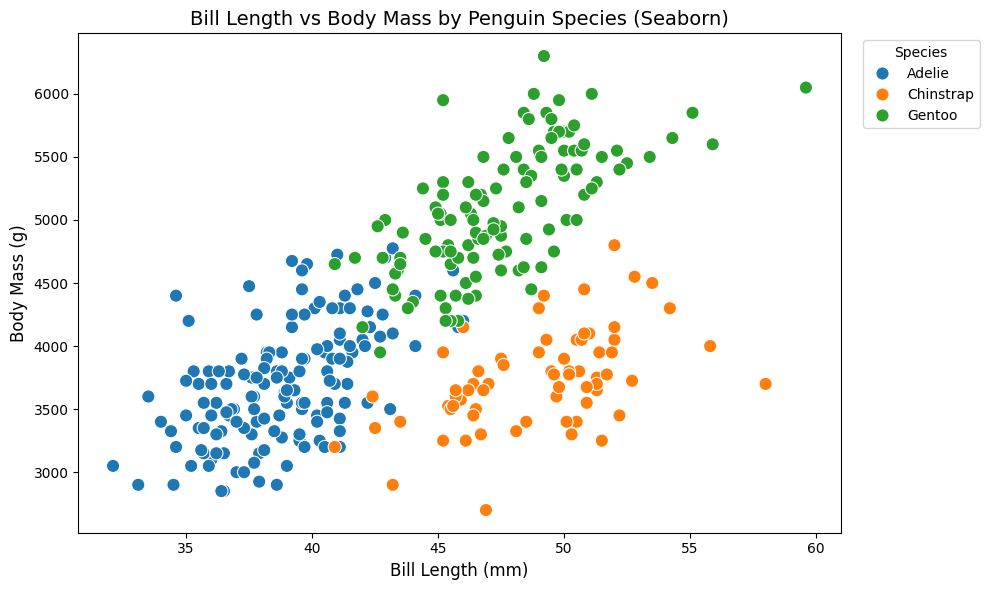

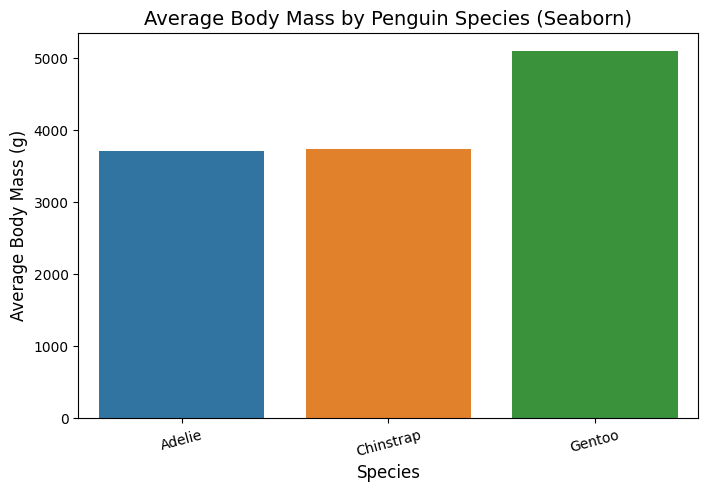

In [7]:
#Part 2
# Seaborn scatter
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=penguins_clean,
    x="bill_length_mm",
    y="body_mass_g",
    hue="species",
    s=90
)

plt.title("Bill Length vs Body Mass by Penguin Species (Seaborn)", fontsize=14)
plt.xlabel("Bill Length (mm)", fontsize=12)
plt.ylabel("Body Mass (g)", fontsize=12)
plt.legend(title="Species", bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=10)
plt.tight_layout()
plt.show()

#Seaborn bar plot
plt.figure(figsize=(8, 5))

sns.barplot(
    data=penguins_clean,
    x="species",
    y="body_mass_g",
    hue="species",
    estimator="mean",
    errorbar=None,
    legend=False
)

plt.title("Average Body Mass by Penguin Species (Seaborn)", fontsize=14)
plt.xlabel("Species", fontsize=12)
plt.ylabel("Average Body Mass (g)", fontsize=12)
plt.xticks(rotation=15)
plt.show()


## Part2
### Seaborn Scatter Plot

This plot shows the relationship between bill length and body mass across penguin species. The seaborn version is easier to create because it automatically handles grouping using the hue parameter and applies a cleaner default style.

### Seaborn Bar Plot

This plot shows the average body mass for each penguin species. The seaborn version produces a more polished visualization with less code compared to matplotlib, while still clearly communicating the differences between species.

## Part 3
### Differences Between Matplotlib and Seaborn

Matplotlib gives more detailed control over each part of a plot, which makes it useful when specific customization is needed. Seaborn is built on top of matplotlib and usually requires less code to create polished and visually appealing graphics. In this assignment, matplotlib felt more manual, while seaborn made it easier to group data and apply attractive default styles. Both are useful, but seaborn is generally faster for exploratory and statistical visualizations, while matplotlib is better for fine-tuned customization.

# Conclusions  

After exploring the Palmer Penguins dataset, I noticed clear differences among penguin species in measurements such as body mass and bill length. Gentoo penguins tended to have the largest average body mass, while the species also showed visible separation in the scatter plot. The dataset was well suited for visualization because it included both numerical and categorical variables. Overall, this assignment showed how matplotlib and seaborn can both be used to present similar information, but with different levels of control and convenience.